In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [35]:
df = pd.read_excel("sign_language_quality_data.xlsx")

In [36]:
target_languages = [
    "American Sign Language",
    "Turkish Sign Language",
    "British Sign Language",
    "Arabic Sign Language"
]

selected_df = df[
    df["language"].isin(target_languages)
].copy()

selected_df


,benchmark,language,year,score,score_label,method,metric,metric_direction,source,notes
0,WLASL test,American Sign Language,2023,58.73,Top-1 quality,SAM-SLR,Top-1 Accuracy,higher_is_better,https://www.wizwand.com/sota/sign-language-rec...,Public benchmark table; ASL isolated recognition.
1,WLASL test,American Sign Language,2025,66.82,Top-1 quality,Multi-dataset co-training,Top-1 Accuracy,higher_is_better,https://www.wizwand.com/sota/sign-language-rec...,Public benchmark table; ASL isolated recognition.
2,WLASL-100,American Sign Language,2025,85.50,Top-1 quality,Siformer,Top-1 Accuracy,higher_is_better,https://www.wizwand.com/sota/sign-language-rec...,WLASL 1.0/100-class skeleton/RGB benchmark table.
3,WLASL-100,American Sign Language,2026,89.37,Top-1 quality,PHONSSM,Top-1 Accuracy,higher_is_better,https://www.wizwand.com/sota/sign-language-rec...,Public benchmark table; WLASL-100.
4,AUTSL,Turkish Sign Language,2023,96.56,Recognition quality,Ryumin et al. STF+LSTM,Gesture recognition rate,higher_is_better,https://www.mdpi.com/1424-8220/23/4/2284,Published Sensors 2023 result on AUTSL.
5,AUTSL,Turkish Sign Language,2025,98.07,Top-1 quality,VideoMAE foundation model,Acc@1,higher_is_better,https://www.researchgate.net/publication/39708...,IEEE Access accepted author version; Table 6.
6,KArSL-100,Arabic Sign Language,2025,89.40,Top-1 quality,SignVLM FSL,Top-1 Accuracy,higher_is_better,https://pmc.ncbi.nlm.nih.gov/articles/PMC12453...,Full supervised learning result from SignVLM T...
7,KArSL-100,Arabic Sign Language,2024,79.30,Top-1 quality,SignVLM FSL,Top-1 Accuracy,higher_is_better,https://pmc.ncbi.nlm.nih.gov/articles/PMC12453...,Full supervised learning result from SignVLM T...
8,WLASL-100,American Sign Language,2024,84.22,Top-1 quality,Siformer,Top-1 Accuracy,higher_is_better,https://www.wizwand.com/sota/sign-language-rec...,WLASL 1.0/100-class skeleton/RGB benchmark table.


In [37]:
counts = selected_df["benchmark"].value_counts()

plot_df = selected_df[
    selected_df["benchmark"].isin(counts[counts > 1].index)
].copy()

plot_df = plot_df.sort_values(["benchmark", "year"])

plot_df[["benchmark", "language", "year", "score", "method"]]


,benchmark,language,year,score,method
4,AUTSL,Turkish Sign Language,2023,96.56,Ryumin et al. STF+LSTM
5,AUTSL,Turkish Sign Language,2025,98.07,VideoMAE foundation model
7,KArSL-100,Arabic Sign Language,2024,79.30,SignVLM FSL
6,KArSL-100,Arabic Sign Language,2025,89.40,SignVLM FSL
0,WLASL test,American Sign Language,2023,58.73,SAM-SLR
1,WLASL test,American Sign Language,2025,66.82,Multi-dataset co-training
8,WLASL-100,American Sign Language,2024,84.22,Siformer
2,WLASL-100,American Sign Language,2025,85.50,Siformer
3,WLASL-100,American Sign Language,2026,89.37,PHONSSM


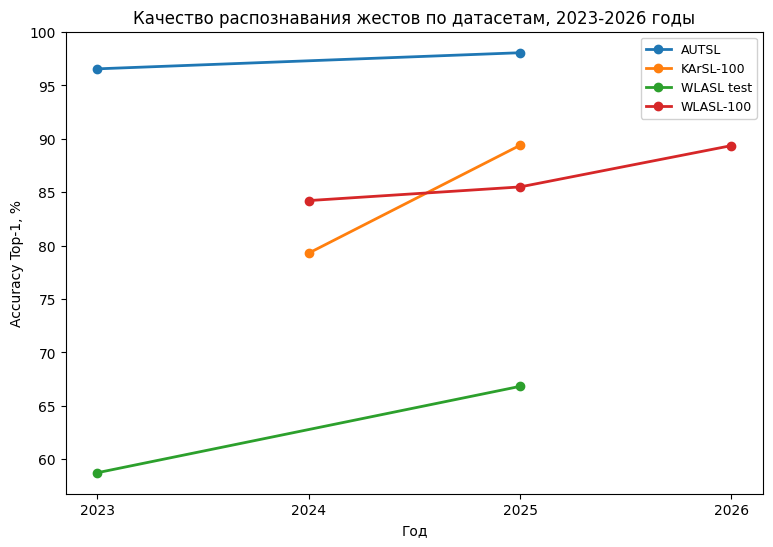

In [43]:
plt.figure(figsize=(9, 6), dpi=100)

for benchmark, group in plot_df.groupby("benchmark"):
    plt.plot(
        group["year"],
        group["score"],
        marker="o",
        linewidth=2,
        label=benchmark,
    )

plt.title("Качество распознавания жестов по датасетам, 2023-2026 годы")
plt.xlabel("Год")
plt.ylabel("Accuracy Top-1, %")
plt.xticks([2023, 2024, 2025, 2026])

plt.legend(
    loc="best",
    frameon=True,
    framealpha=0.9,
    fontsize=9,
)

plt.show()


In [44]:
plt.savefig("recognition_quality_23-26.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>